In [2]:
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

In [3]:
df = yf.download(tickers=['AAPL'],period='1mo',interval='5m');

[*********************100%***********************]  1 of 1 completed


In [4]:
df

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Datetime,,,,,
2026-04-28 18:05:00+00:00,270.380005,270.915009,270.120087,270.380096,0
2026-04-28 18:10:00+00:00,270.519989,270.600006,270.299988,270.375000,232383
2026-04-28 18:15:00+00:00,270.619995,270.690002,270.450012,270.519989,171800
2026-04-28 18:20:00+00:00,270.590088,270.739990,270.450012,270.630005,224287
2026-04-28 18:25:00+00:00,270.500000,270.690002,270.480011,270.609985,168174
...,...,...,...,...,...
2026-05-28 17:45:00+00:00,310.630005,310.769989,310.489990,310.654999,273577
2026-05-28 17:50:00+00:00,310.249908,310.690002,310.109985,310.640015,375111


In [5]:
n = 10
df['ROC'] = (df['Close'] - df['Close'].shift(n)) / df['Close'].shift(n) * 100

A. Rate of Change (ROC)

Simple momentum.

ROC= ((Closeₜ - close(ₜ-n))/close(ₜ-n)) x 100

Positive → bullish momentum

Negative → bearish momentum

In [6]:
df['ROC']

Datetime
2026-04-28 18:05:00+00:00         NaN
2026-04-28 18:10:00+00:00         NaN
2026-04-28 18:15:00+00:00         NaN
2026-04-28 18:20:00+00:00         NaN
2026-04-28 18:25:00+00:00         NaN
                               ...   
2026-05-28 17:45:00+00:00    0.016105
2026-05-28 17:50:00+00:00   -0.332523
2026-05-28 17:55:00+00:00   -0.220970
2026-05-28 18:00:00+00:00   -0.128673
2026-05-28 18:05:00+00:00   -0.109351
Name: ROC, Length: 1639, dtype: float64

In [7]:
max_roc = df['ROC'].max()
min_roc = df['ROC'].min()
print(f"Maximum ROC: {max_roc}")
print(f"Minimum ROC: {min_roc}")

Maximum ROC: 5.207107033303479
Minimum ROC: -1.8449516599751303


In [8]:
df.describe()

Price,Close,High,Low,Open,Volume,ROC
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,
count,1639.000000,1639.000000,1639.000000,1639.000000,1.639000e+03,1629.000000
mean,293.527078,293.790739,293.238846,293.507721,4.622008e+05,0.086576
std,12.236177,12.227505,12.247723,12.237230,7.659964e+05,0.530442
min,268.195007,268.649902,267.200012,267.859894,0.000000e+00,-1.844952
25%,284.664993,284.945007,284.210007,284.639999,2.228950e+05,-0.190748
50%,295.674988,295.920013,295.369995,295.609985,3.105010e+05,0.042832
75%,301.757492,302.049988,301.354996,301.699997,4.634300e+05,0.276280
max,313.059998,313.260010,312.920013,313.070007,1.631315e+07,5.207107


In [9]:
df.isnull().sum()

Price   Ticker
Close   AAPL       0
High    AAPL       0
Low     AAPL       0
Open    AAPL       0
Volume  AAPL       0
ROC               10
dtype: int64

In [10]:
df.columns

MultiIndex([( 'Close', 'AAPL'),
            (  'High', 'AAPL'),
            (   'Low', 'AAPL'),
            (  'Open', 'AAPL'),
            ('Volume', 'AAPL'),
            (   'ROC',     '')],
           names=['Price', 'Ticker'])

In [11]:
numeric_columns = ['Open', 'High', 'Low', 'Close', 'Volume']

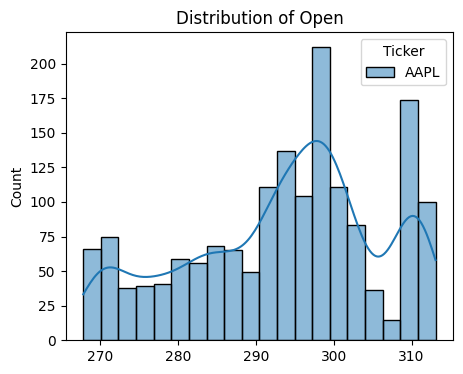

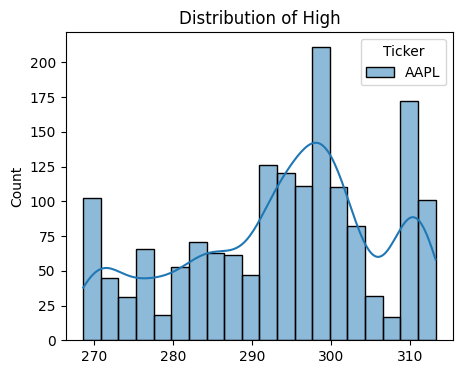

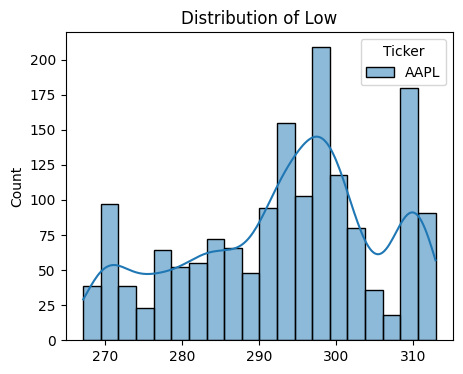

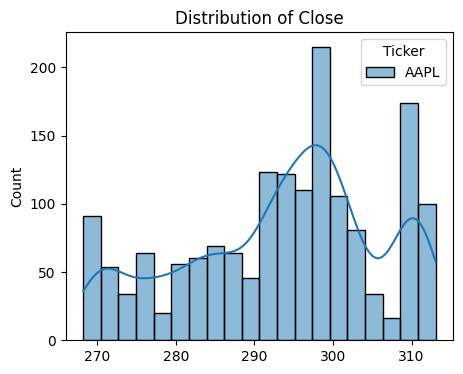

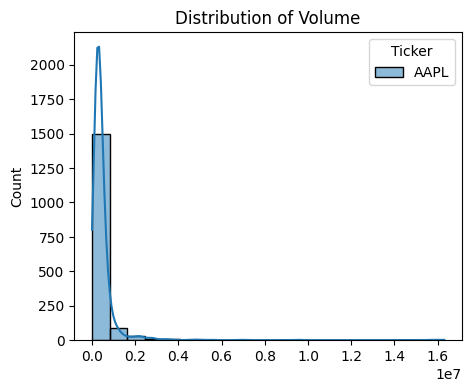

In [12]:
for col in numeric_columns:
  plt.figure(figsize=(5, 4))
  sns.histplot(df[col], kde=True, bins=20)
  #kde -> kernel density estimation
  plt.title(f'Distribution of {col}')
  plt.show()


In [17]:
df.columns = [col[0] if col[1]=='' else f'{col[0]}_{col[1]}' for col in df.columns]

print(df.columns)

Index(['Close_AAPL', 'High_AAPL', 'Low_AAPL', 'Open_AAPL', 'Volume_AAPL',
       'ROC'],
      dtype='str')


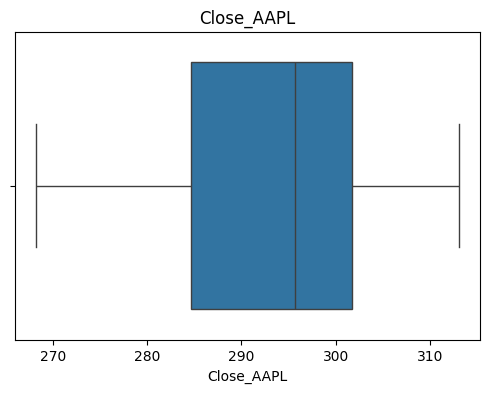

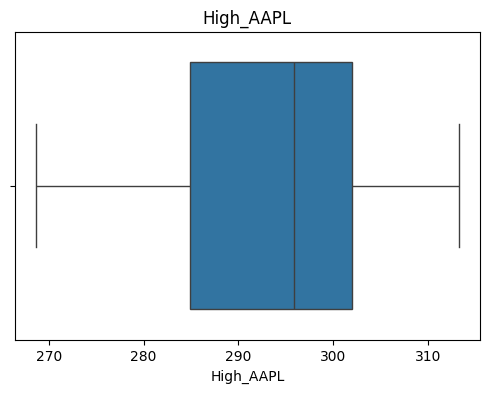

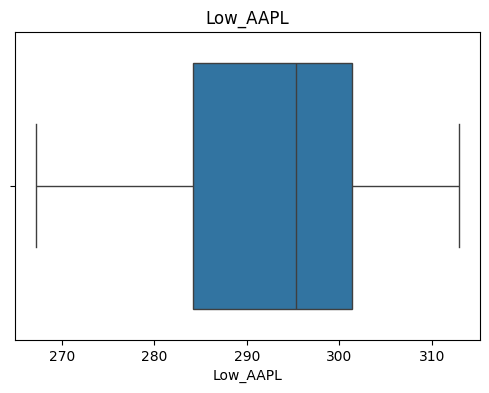

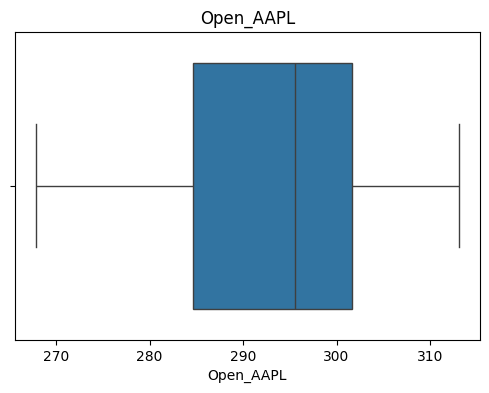

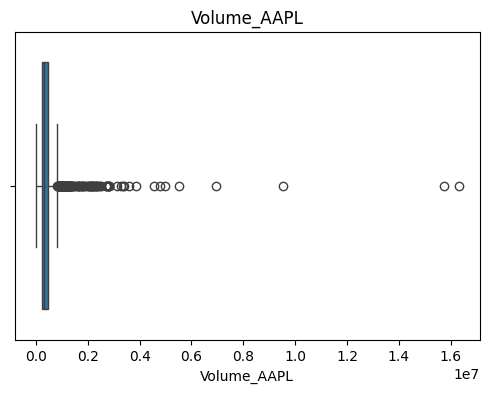

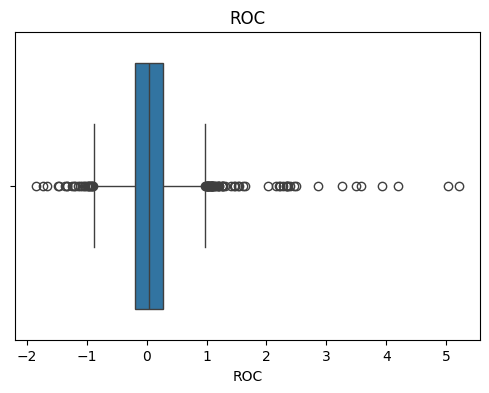

In [18]:
numeric_columns = df.select_dtypes(include='number').columns

for col in numeric_columns:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col].dropna())
    plt.title(col)
    plt.show()

<Axes: >

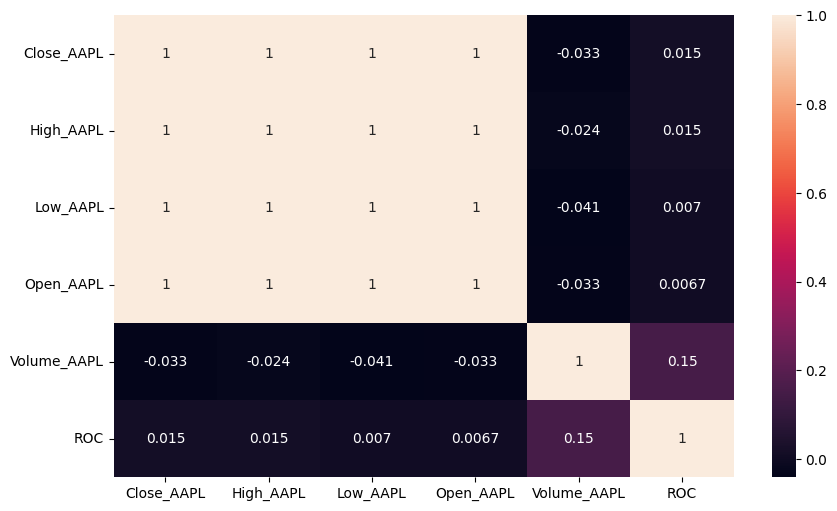

In [19]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True)